In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("airline-passengers.csv")

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
print(df.info())

print("\nShape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None

Shape: (144, 2)

Missing Values:
Month         0
Passengers    0
dtype: int64


In [4]:
df['Month'] = pd.to_datetime(df['Month'])

df.set_index('Month', inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


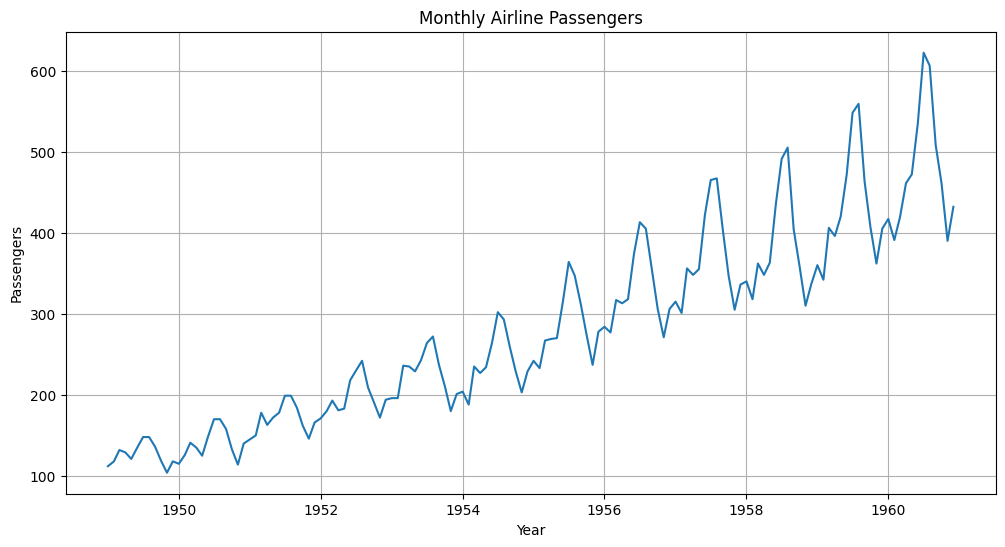

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df['Passengers'])

plt.title("Monthly Airline Passengers")

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.grid(True)

plt.show()


In [7]:
quarterly = df.resample('Q').mean()

quarterly.head()

,Passengers
Month,
1949-03-31,120.666667
1949-06-30,128.333333
1949-09-30,144.000000
1949-12-31,113.666667
1950-03-31,127.333333


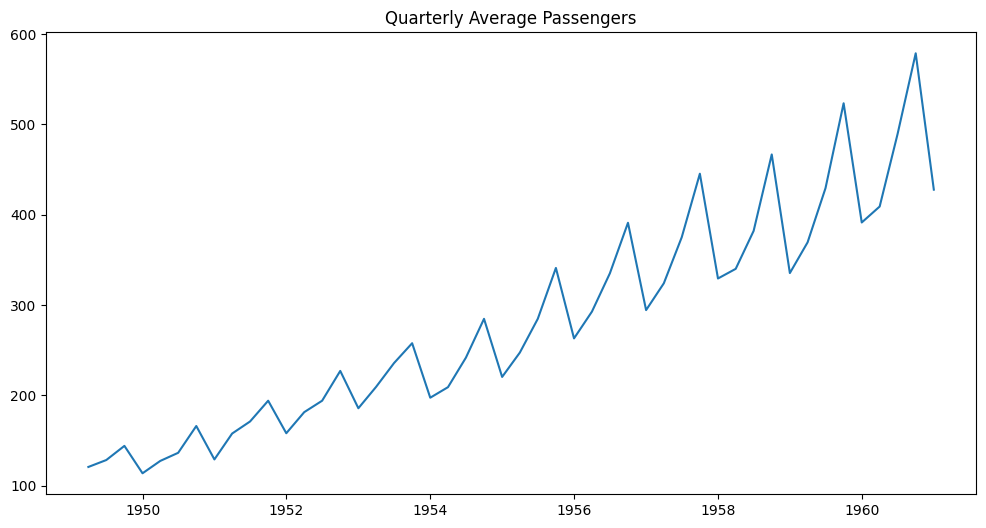

In [8]:
plt.figure(figsize=(12,6))

plt.plot(quarterly)

plt.title("Quarterly Average Passengers")

plt.show()

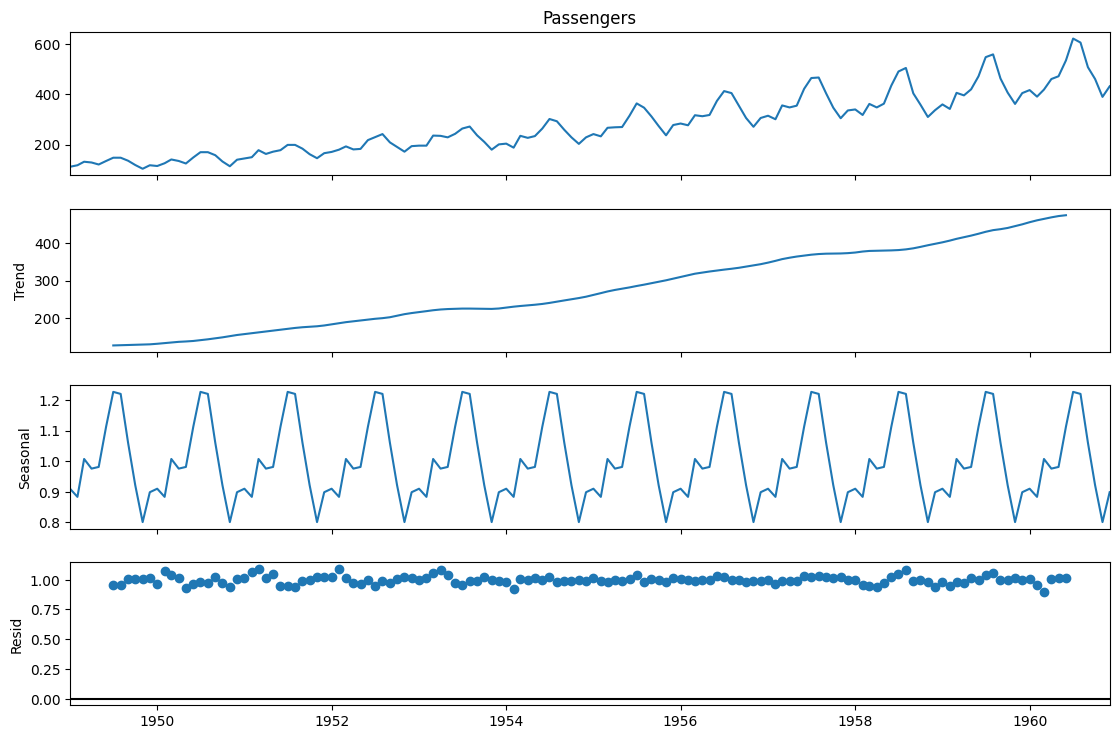

In [9]:
decomposition = seasonal_decompose(
    df['Passengers'],
    model='multiplicative',
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(12,8)

plt.show()

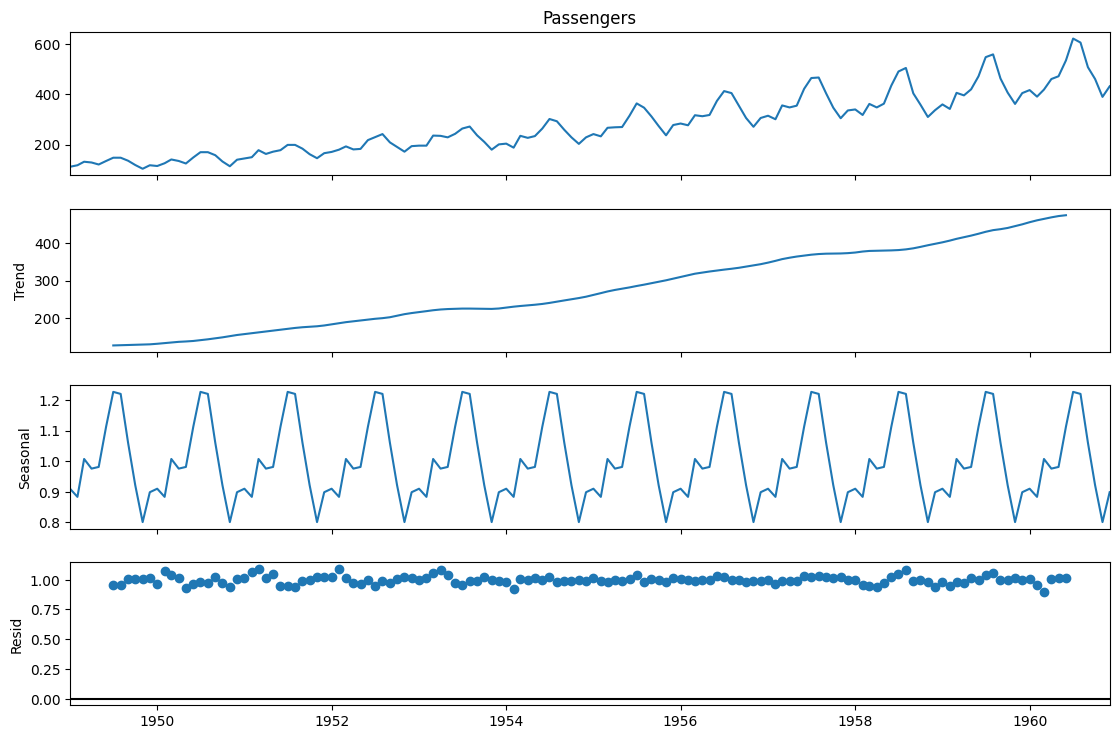

In [10]:
decomposition = seasonal_decompose(
    df['Passengers'],
    model='multiplicative',
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(12,8)

plt.show()

In [11]:
df['MA_6'] = df['Passengers'].rolling(6).mean()

df['MA_12'] = df['Passengers'].rolling(12).mean()

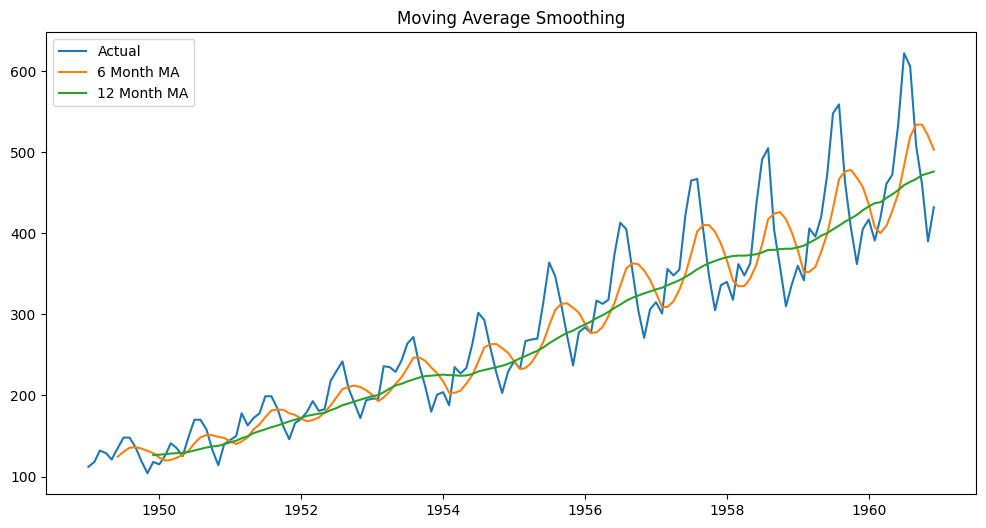

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df['Passengers'], label='Actual')

plt.plot(df['MA_6'], label='6 Month MA')

plt.plot(df['MA_12'], label='12 Month MA')

plt.legend()

plt.title("Moving Average Smoothing")

plt.show()

In [13]:
train = df['Passengers'][:-12]

test = df['Passengers'][-12:]

print("Training Samples:", len(train))

print("Testing Samples:", len(test))

Training Samples: 132
Testing Samples: 12


In [14]:
model = SARIMAX(
    train,
    order=(2,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -445.700
Date:                            Wed, 03 Jun 2026   AIC                            903.399
Time:                                    10:35:30   BIC                            920.074
Sample:                                01-01-1949   HQIC                           910.171
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5062      1.365     -0.371      0.711      -3.181       2.168
ar.L2         -0.0033      0.399   

In [15]:
forecast = result.forecast(
    steps=len(test)
)

forecast

,predicted_mean
1960-01-01,421.877485
1960-02-01,405.424550
1960-03-01,464.696999
1960-04-01,453.476362
1960-05-01,477.274412
1960-06-01,534.835426
1960-07-01,609.460547
1960-08-01,621.592159
1960-09-01,522.623641
1960-10-01,467.952979


In [16]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("RMSE:", rmse)

RMSE: 21.16996463074816


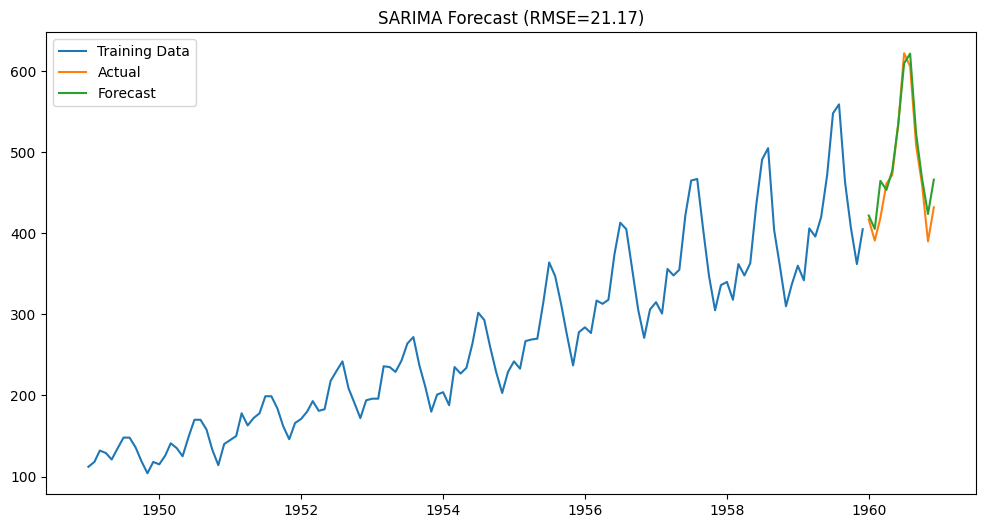

In [17]:

plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    label="Forecast"
)

plt.legend()

plt.title(f"SARIMA Forecast (RMSE={rmse:.2f})")

plt.show()

In [18]:
future_forecast = result.forecast(
    steps=12
)

future_forecast

,predicted_mean
1960-01-01,421.877485
1960-02-01,405.424550
1960-03-01,464.696999
1960-04-01,453.476362
1960-05-01,477.274412
1960-06-01,534.835426
1960-07-01,609.460547
1960-08-01,621.592159
1960-09-01,522.623641
1960-10-01,467.952979


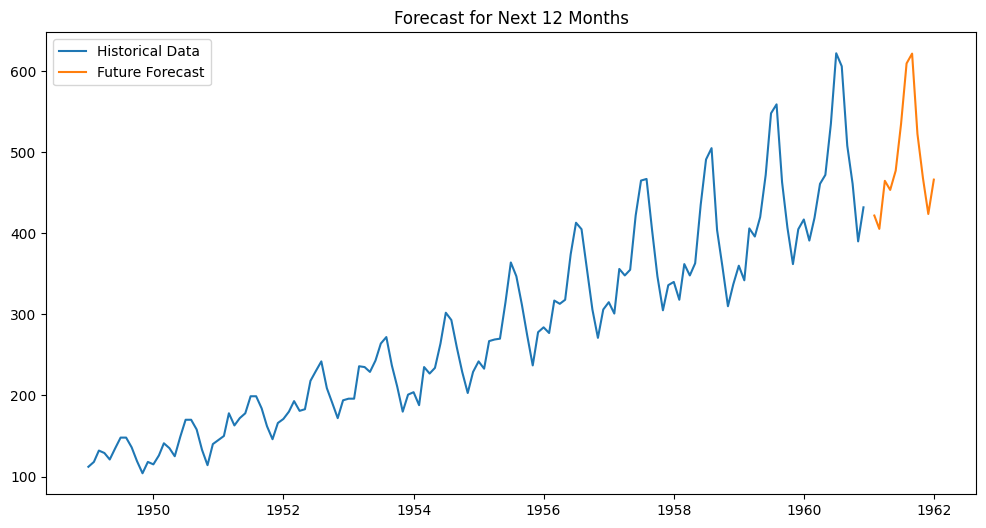

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    df['Passengers'],
    label='Historical Data'
)

future_dates = pd.date_range(
    start=df.index[-1],
    periods=13,
    freq='M'
)[1:]

plt.plot(
    future_dates,
    future_forecast,
    label='Future Forecast'
)

plt.legend()

plt.title("Forecast for Next 12 Months")

plt.show()